In [168]:
import numpy as np
import matplotlib.pyplot as plt

df = np.loadtxt('https://raw.githubusercontent.com/julihdez36/Funda_ciencia_dat/refs/heads/main/scientific/creditcard.csv', delimiter= ',', skiprows= 1, dtype= float)

In [2]:
df.ndim, df.shape

(2, (284807, 31))

#### Análsis y exploración de datos [EDA]

1. Métodos numéricos
2. Métodos tabulares
3. Métodos gráficos

In [160]:
# Definamos la matriz de características X

X = df[:,:-1]

# Definamos el vector de salida y

y = df[:,-1] # Todos los registros de la última columna

In [16]:
X.shape, y.shape, df.shape

((284807, 30), (284807,), (284807, 31))

In [ ]:
y = np.array([int(i) for i in y])
y

array([0, 0, 0, ..., 0, 0, 0], shape=(284807,))

In [29]:
# Exploremos el vector de salida 

etiqueta, conteo = np.unique(y, return_counts= True) # unpackage

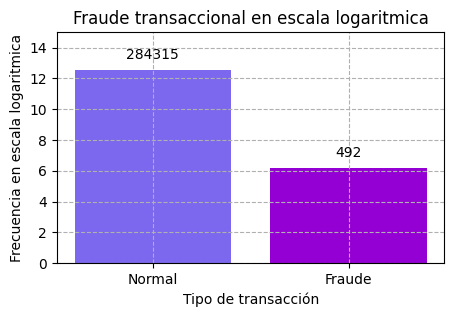

In [78]:
plt.figure(figsize= (5,3))
plt.bar(['Normal', 'Fraude'], np.log(conteo), color = ['mediumslateblue','darkviolet'])
plt.title('Fraude transaccional en escala logaritmica')
plt.ylabel('Frecuencia en escala logaritmica')
plt.xlabel('Tipo de transacción')
plt.grid(ls = 'dashed')
plt.text(0, np.log(conteo[0]) + .5, conteo[0], ha='center', va='bottom')
plt.text(1, np.log(conteo[1]) + .5, conteo[1], ha='center', va='bottom')
plt.ylim(0,15)
plt.show()

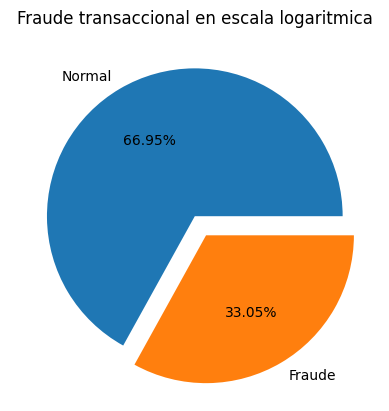

In [88]:
plt.pie(x = np.log(conteo), labels= ['Normal', 'Fraude'], explode= [0, .15], autopct= '%1.2f%%')
plt.title('Fraude transaccional en escala logaritmica')
plt.grid(ls = 'dashed')
plt.show()

In [90]:
X[:,-1]

array([149.62,   2.69, 378.66, ...,  67.88,  10.  , 217.  ],
      shape=(284807,))

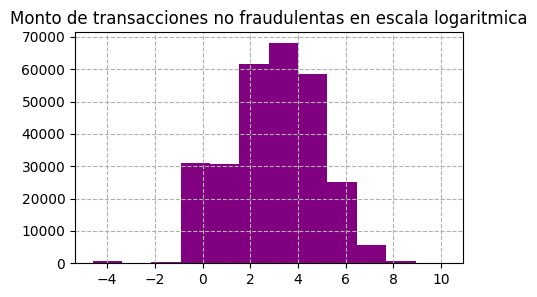

In [131]:
plt.figure(figsize= (5,3))
plt.hist([np.log(i) for i in X[y == 0,-1] if i != 0], bins = 12, color = 'purple', histtype = 'barstacked')
plt.grid(ls = 'dashed')
plt.title('Monto de transacciones no fraudulentas en escala logaritmica')
plt.show()

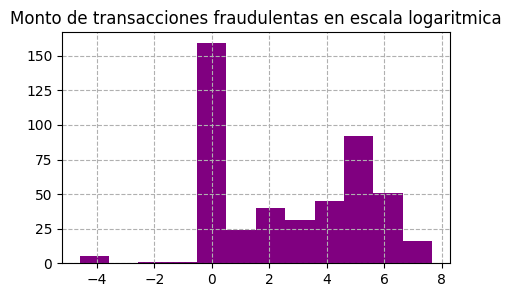

In [134]:
plt.figure(figsize= (5,3))
plt.hist([np.log(i) for i in X[y == 1,-1] if i != 0], bins = 12, color = 'purple', histtype = 'barstacked')
plt.grid(ls = 'dashed')
plt.title('Monto de transacciones fraudulentas en escala logaritmica')
plt.show()

C:\Windows\Temp\ipykernel_20136\334874948.py:2: RuntimeWarning: divide by zero encountered in log
  plt.scatter(np.log(X[:,0]), X[:,7])


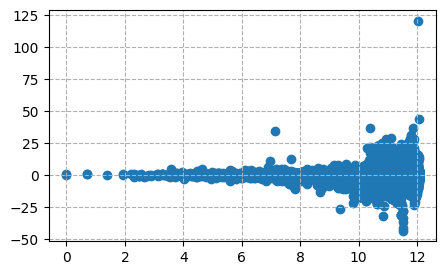

In [113]:
plt.figure(figsize= (5,3))
plt.scatter(np.log(X[:,0]), X[:,7])
plt.grid(ls = 'dashed')
plt.show()

C:\Windows\Temp\ipykernel_20136\914414917.py:2: RuntimeWarning: divide by zero encountered in log
  plt.scatter(np.log(X[y == 0,0]), X[y == 0,7])


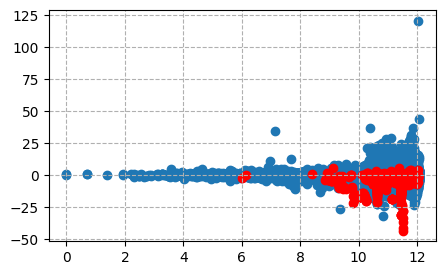

In [127]:
plt.figure(figsize= (5,3))
plt.scatter(np.log(X[y == 0,0]), X[y == 0,7])
plt.scatter(np.log(X[y == 1,0]), X[y == 1,7], color = 'red')
plt.grid(ls = 'dashed')
plt.show()

#### Predicción de fraudes transaccionales

In [135]:
def funcion_lineal(x,m,b):
    return m*x +b

In [139]:
x = np.linspace(0,100,100)
m = 2
b = 3

y = funcion_lineal(x,m,b)

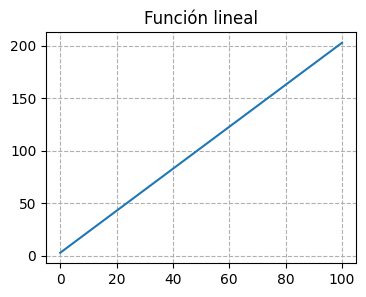

In [147]:
plt.figure(figsize=(4,3))
plt.plot(x,y)
plt.title('Función lineal')
plt.grid(ls = 'dashed')
plt.show()

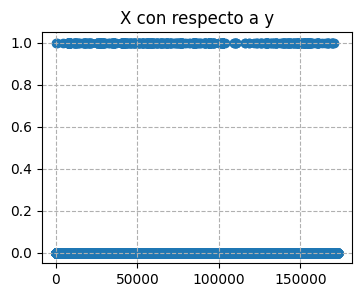

In [150]:
plt.figure(figsize=(4,3))
plt.scatter(X[:,0], y)
plt.title('X con respecto a y')
plt.grid(ls = 'dashed')
plt.show()

In [151]:
def funcion_logistica(x, L, k, x0):
    return 1 / (1 + np.exp(-k * (x - x0)))

x = np.linspace(-10, 10, 400)
L = 1
k = 1
x0 = 0

y_logis = funcion_logistica(x,L,k,x0)

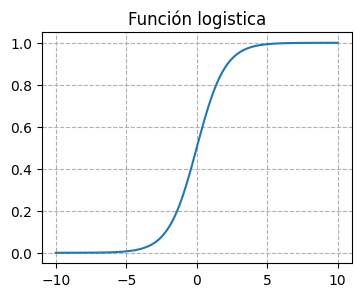

In [152]:
plt.figure(figsize=(4,3))
plt.plot(x,y_logis)
plt.title('Función logistica')
plt.grid(ls = 'dashed')
plt.show()

In [163]:
# División del conjnuto en entrenamiento y testeo

n = y.shape[0]
idx = list(range(0))
np.random.shuffle(idx)

train_idx = idx[:int(.8*n)]
test_idx = idx[int(.8*n):]

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[train_idx], y[train_idx]

In [164]:
# Escalamiento

mean = X_train.mean(axis=0)
std = X_train.std(axis=0) + 1e-8
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

# Añadimos intercepto (columna de unos)
X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_test = np.c_[np.ones(X_test.shape[0]), X_test]

C:\Windows\Temp\ipykernel_20136\2430368438.py:3: RuntimeWarning: Mean of empty slice.
  mean = X_train.mean(axis=0)


In [165]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def log_loss(y, h):
    return -(y*np.log(h+1e-8) + (1-y)*np.log(1-h+1e-8)).mean()

In [166]:
# Función de descenso de gradiente

n_samples, n_features = X_train.shape
theta = np.zeros(n_features)

lr = 0.1
epochs = 500

loss_history = []

for i in range(epochs):
    z = X_train @ theta
    h = sigmoid(z)
    error = h - y_train
    grad = (X_train.T @ error) / n_samples
    theta -= lr * grad
    
    # guardar pérdida
    loss = log_loss(y_train, h)
    loss_history.append(loss)


C:\Windows\Temp\ipykernel_20136\2321839247.py:15: RuntimeWarning: invalid value encountered in divide
  grad = (X_train.T @ error) / n_samples
C:\Windows\Temp\ipykernel_20136\2915087196.py:5: RuntimeWarning: Mean of empty slice.
  return -(y*np.log(h+1e-8) + (1-y)*np.log(1-h+1e-8)).mean()


In [167]:
probs = sigmoid(X_test @ theta)
y_pred = (probs >= 0.5).astype(int)

accuracy = (y_pred == y_test).mean()
print("Accuracy en test:", accuracy)
print("Theta aprendidos:", theta)

Accuracy en test: nan
Theta aprendidos: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan]


C:\Windows\Temp\ipykernel_20136\2983875258.py:4: RuntimeWarning: Mean of empty slice.
  accuracy = (y_pred == y_test).mean()


Accuracy en test: 0.9990344440153085
Theta aprendidos: [-3.83238722e+00 -1.37944382e-03 -2.54191814e-02  3.01350901e-02
 -6.59837790e-02  6.38082717e-02 -1.63403731e-02 -1.73775734e-02
 -5.71516764e-02 -1.14628076e-02 -4.06194418e-02 -8.68258333e-02
  6.56777225e-02 -1.04991461e-01 -7.09244012e-03 -1.45842161e-01
 -2.57897954e-03 -6.86411264e-02 -1.03144124e-01 -2.99798739e-02
  8.94244124e-03  4.46031688e-03  1.70117183e-02  1.91226205e-03
 -2.64480899e-03 -5.06310531e-03 -1.13830332e-03  3.44817632e-03
  4.94055831e-03  3.37737782e-03  6.46931893e-03]


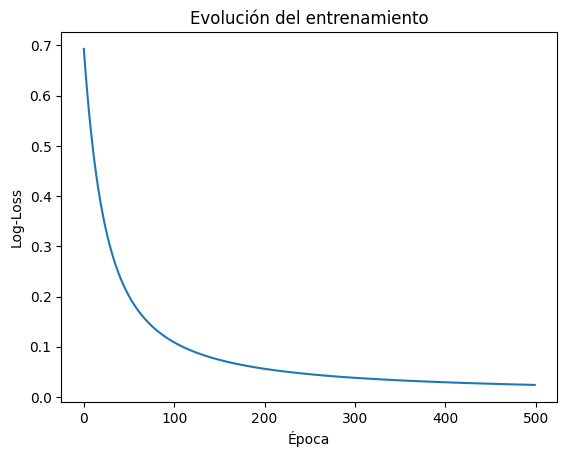

In [169]:
y = df[:,-1]
y = np.array([int(i) for i in y])

X = df[:,:30]
y.shape, X.shape

n = y.shape[0]

idx = list(range(n))
np.random.shuffle(idx)

train_idx = idx[:int(0.8 * n)] # hasta
test_idx = idx[int(0.8 * n):] # Desde

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

# =====================
# 3. Preparar datos
# =====================
# Escalamos features para mejor convergencia
mean = X_train.mean(axis=0)
std = X_train.std(axis=0) + 1e-8
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

# Añadimos intercepto (columna de unos)
X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_test = np.c_[np.ones(X_test.shape[0]), X_test]

# =====================
# 4. Definir funciones matemáticas básicas
# =====================
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def log_loss(y, h):
    return -(y*np.log(h+1e-8) + (1-y)*np.log(1-h+1e-8)).mean()

# =====================
# 5. Entrenamiento con descenso de gradiente
# =====================

n_samples, n_features = X_train.shape
theta = np.zeros(n_features)

lr = 0.1
epochs = 500

loss_history = []

for i in range(epochs):
    z = X_train @ theta
    h = sigmoid(z)
    error = h - y_train
    grad = (X_train.T @ error) / n_samples
    theta -= lr * grad
    
    # guardar pérdida
    loss = log_loss(y_train, h)
    loss_history.append(loss)

# =====================
# 6. Evaluación
# =====================
probs = sigmoid(X_test @ theta)
y_pred = (probs >= 0.5).astype(int)

accuracy = (y_pred == y_test).mean()
print("Accuracy en test:", accuracy)
print("Theta aprendidos:", theta)

# =====================
# 7. Gráfica de la pérdida
# =====================
plt.plot(loss_history)
plt.xlabel("Época")
plt.ylabel("Log-Loss")
plt.title("Evolución del entrenamiento")
plt.show()